In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("PrePlacement.csv")

In [3]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [4]:
import seaborn as sns

In [5]:
print(dataset.columns)

Index(['sl_no', 'gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s',
       'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p',
       'status', 'salary'],
      dtype='object')


<Axes: xlabel='ssc_p', ylabel='Count'>

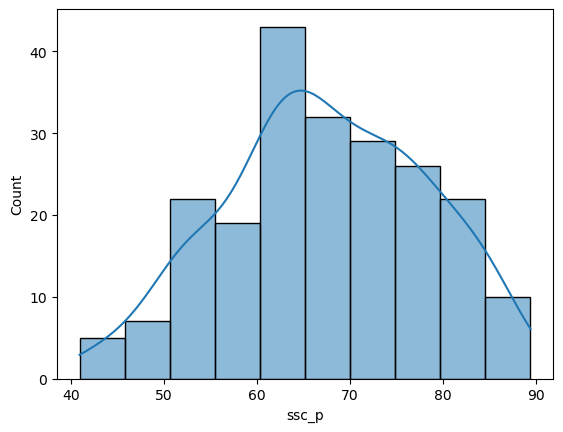

In [6]:
sns.histplot(dataset["ssc_p"],kde=True)

In [7]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    import numpy as np
  

    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    

    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)

    # Shade area between start and end - For my own purpose tried this code
    ## x_fill = np.linspace(startrange, endrange, 500)
    ## y_fill = norm.pdf(x_fill, sample_mean, sample_std)
    ## pyplot.fill_between(x_fill, y_fill, color="orange",alpha=0.4,label="Probability Area")
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob
    

Mean=67.303, Standard Deviation=10.827
The area between range(40,60):0.23035961179550077


C:\Users\xsanthkum\AppData\Local\Temp\ipykernel_35216\3302791096.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


np.float64(0.23035961179550077)

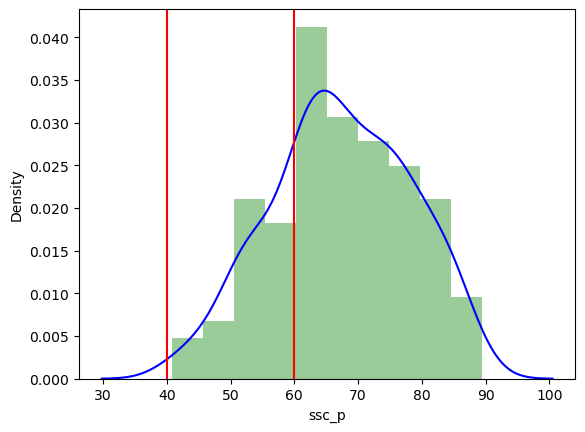

In [8]:
get_pdf_probability(dataset["ssc_p"],40,60)

In [9]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF(dataset['ssc_p'])
ecdf(80) # changing the value inside ecdf(80) provides the % of student who scored marks in the value

np.float64(0.8651162790697674)

In [10]:
#!pip install statsmodels

In [11]:
def stdNBgraph(dataset):
        # Coverted to standard Normal Distribution
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]

    z_score=[((j-mean)/std) for j in values]

    sns.histplot(z_score,kde=True)

    sum(z_score)/len(z_score)
    #z_score.std()


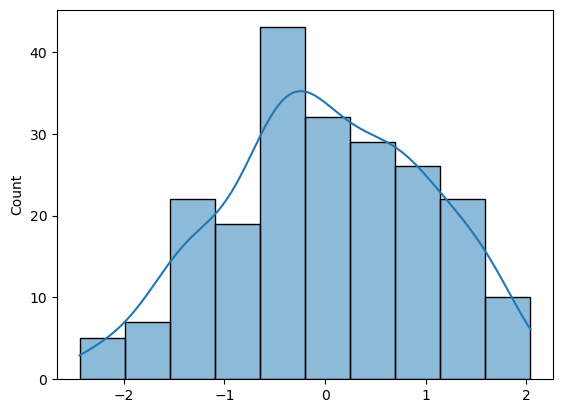

In [12]:
stdNBgraph(dataset["ssc_p"])